__Markus Mulvihill__

__Last updated May 2026__

# Necessary Packages and Modules

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tomllib

# Introduction

This file examines the accuracy and time complexity of the extended Kalman filter and the particle filter with various number of particles.

In [2]:
try:
    time_arr_03 = np.load("../scripts/variables/time_arr_03_temp.npy")
    error_arr_03 = np.load("../scripts/variables/error_arr_03_temp.npy")
    G_ests = np.load("../scripts/variables/G_ests_03_temp.npy")
    print("Loaded variables")
except Exception:
    print("Run 03_Estimator3Comparison.py")

Loaded variables


In [3]:
with open("../config.toml", "rb") as f:
    cfg = tomllib.load(f)
curr_module = "03"
num_particles = cfg[curr_module]["num_particles"]
low_perc = cfg[curr_module]["low_perc"]
high_perc = cfg[curr_module]["high_perc"]
CI = cfg[curr_module]["CI"]
converge_time = cfg[curr_module]["converge_time"]
deviations = cfg[curr_module]["deviations"]
dev_perc = cfg[curr_module]["dev_perc"]
plot_particles_idx = cfg[curr_module]["plot_particles_idx"]
num_deviations = len(deviations)

# Plot Results

<Axes: xlabel='Estimator', ylabel='Time to run (s)'>

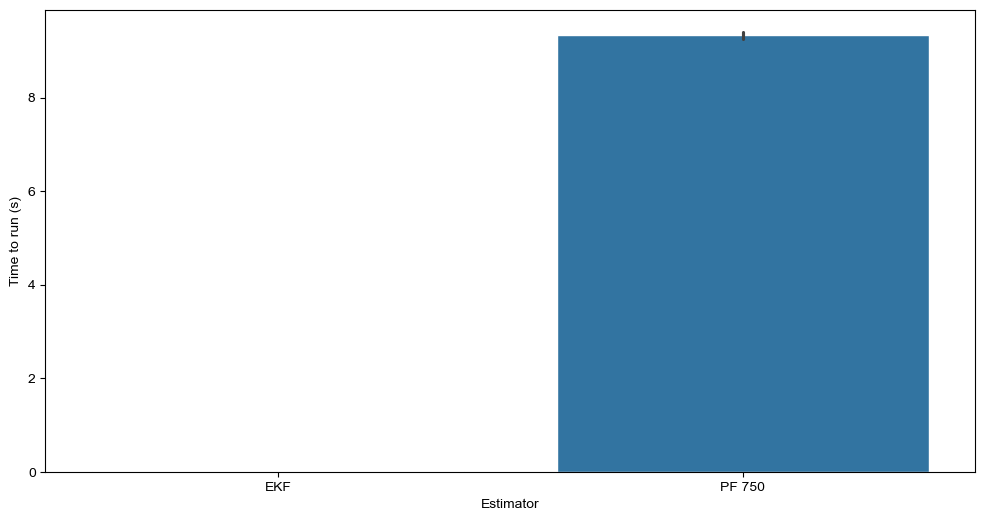

In [4]:
mean_time_run = np.average(time_arr_03[0, :, :].T, axis=0)
filters = ["EKF"]
pfs = [f"PF {particles}" for particles in num_particles]
filters.extend(pfs)
df = pd.DataFrame(time_arr_03[0, :, :].T, columns=filters).melt(
    var_name="Estimator", value_name="Time to run (s)"
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.set_style("whitegrid")
sns.barplot(df, x="Estimator", y="Time to run (s)", ax=ax)

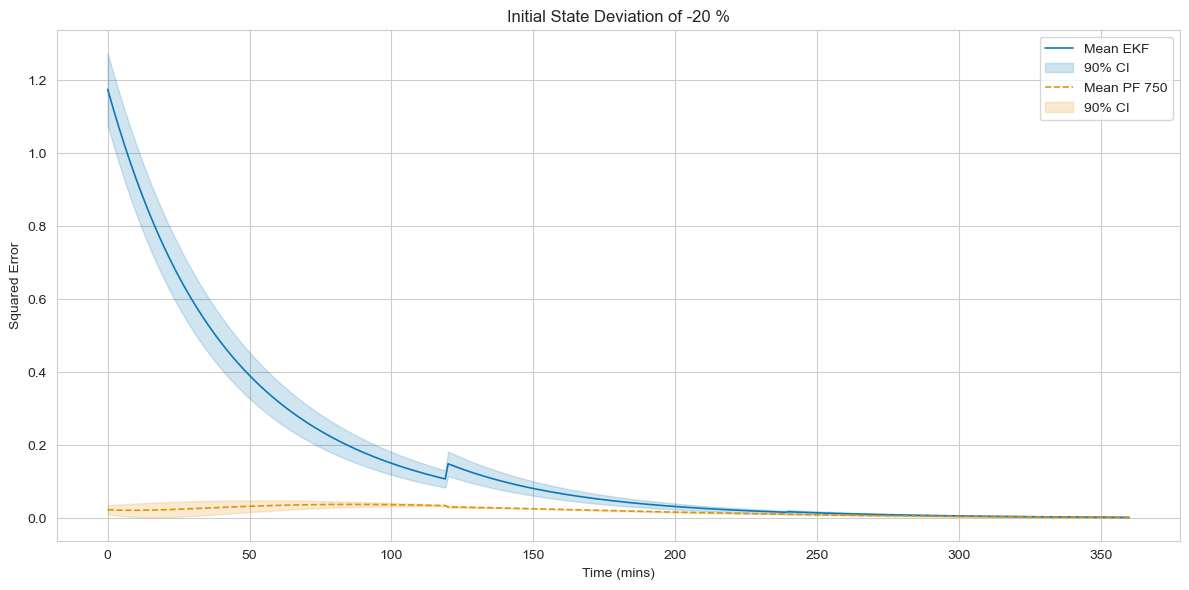

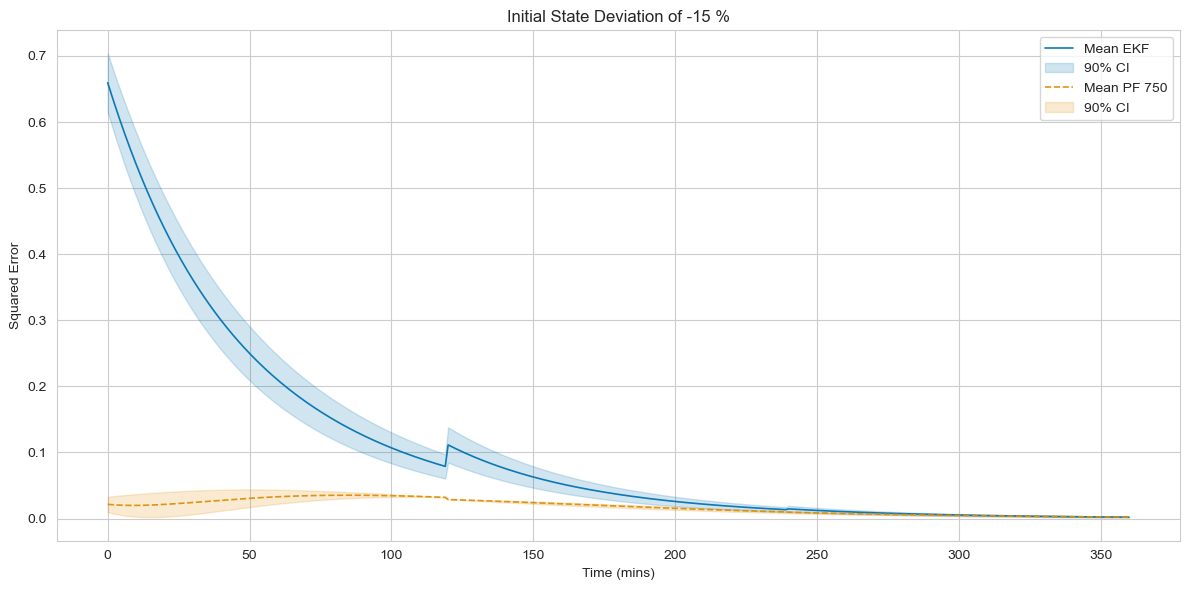

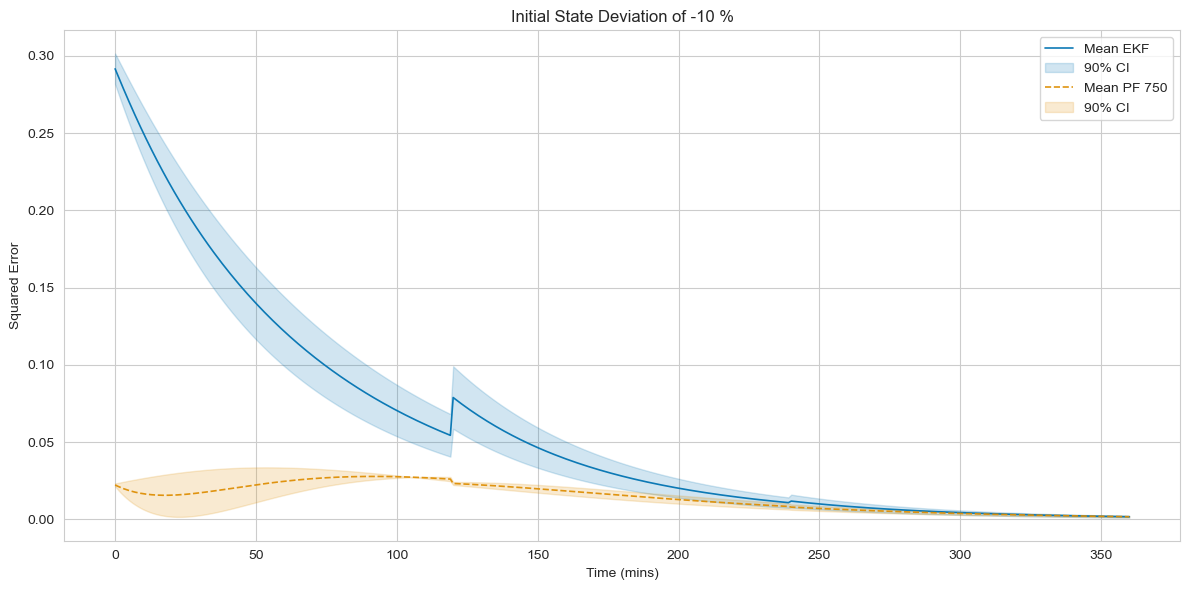

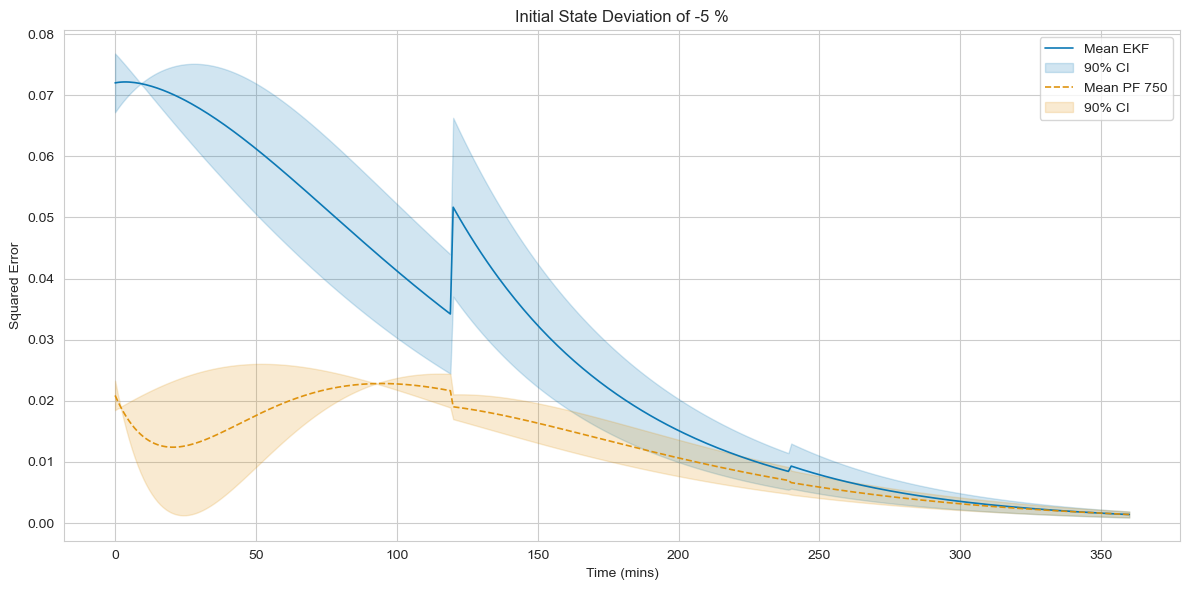

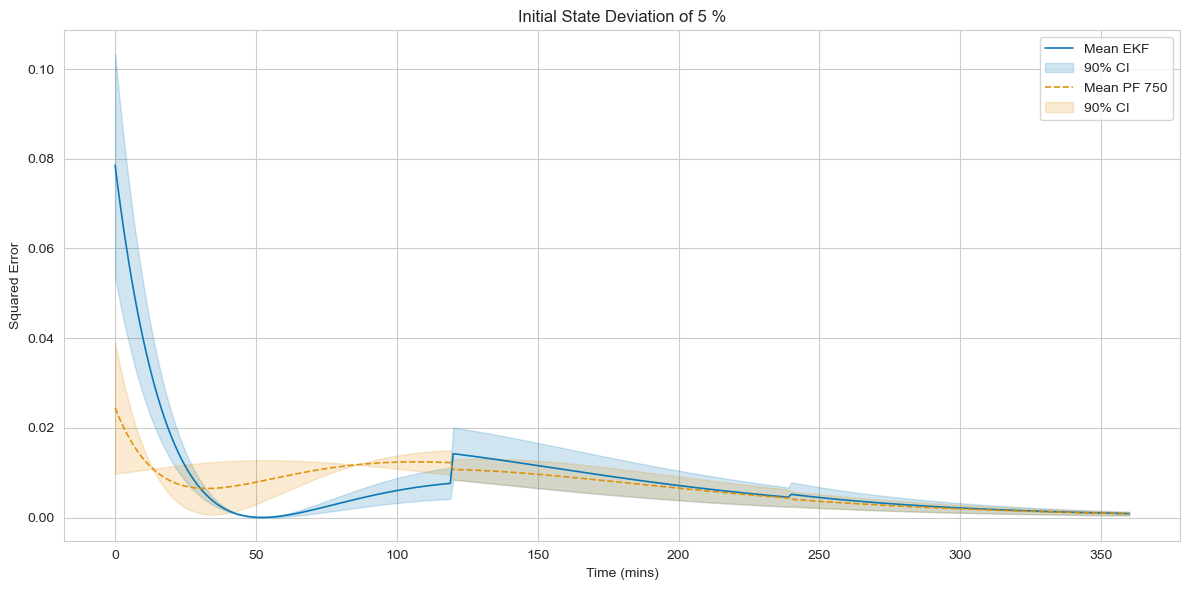

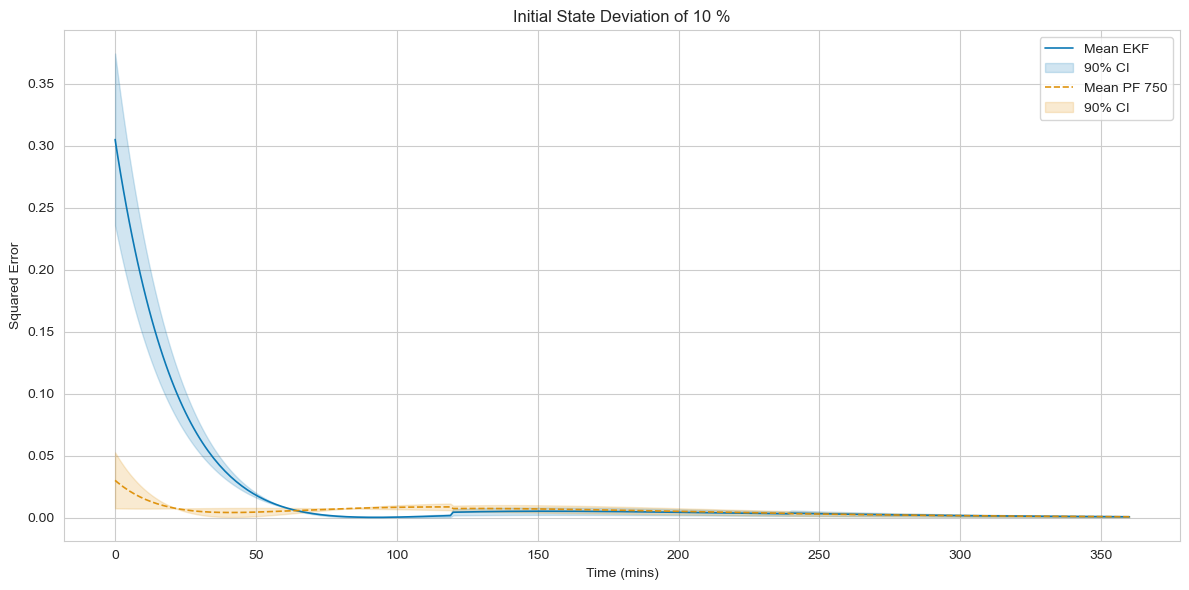

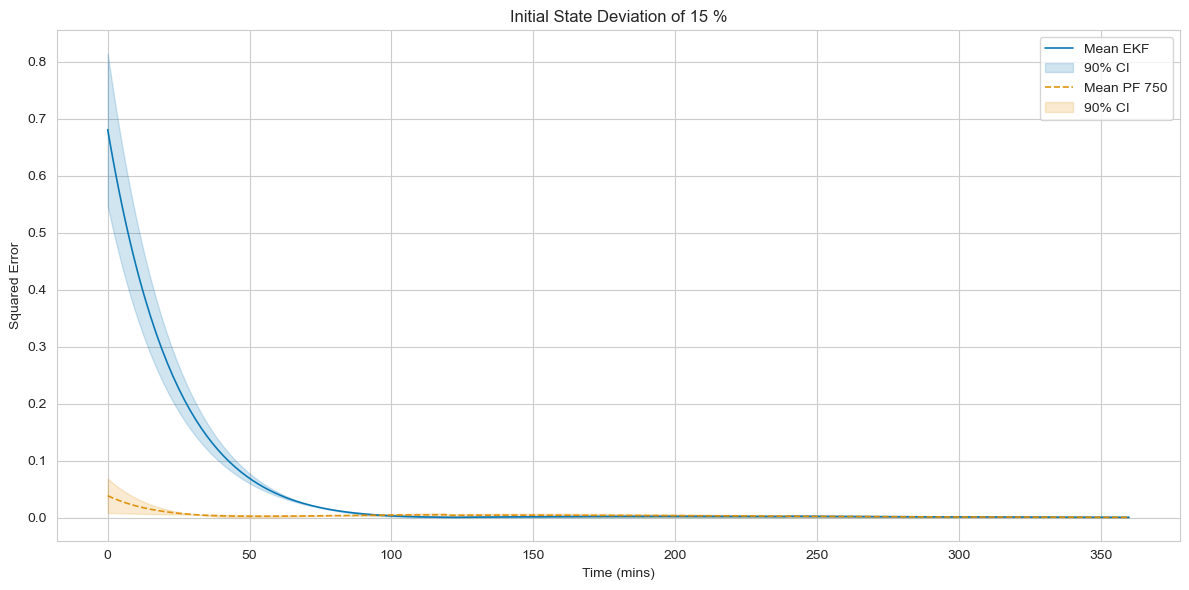

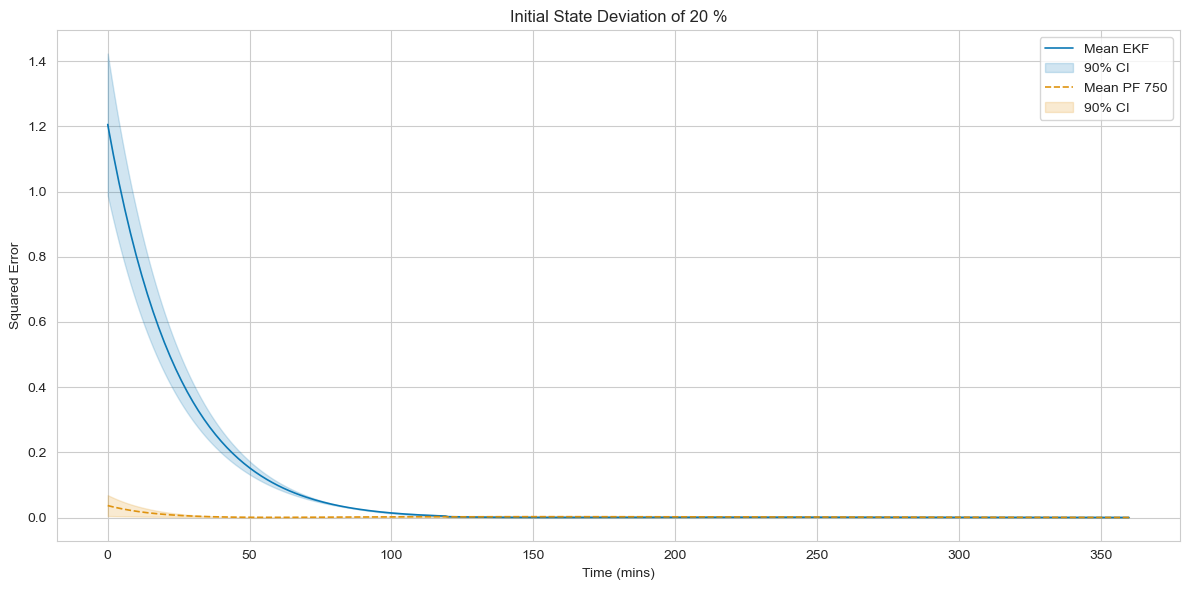

In [5]:
for j in range(num_deviations):
    mean_err = np.mean(error_arr_03[j, :, :, :], axis=1)
    ci_low = np.percentile(error_arr_03[j, :, :, :], low_perc, axis=1)
    ci_high = np.percentile(error_arr_03[j, :, :, :], high_perc, axis=1)
    time = np.arange(mean_err.shape[1])
    num_plots = len(plot_particles_idx)  # 
    num_filters = len(filters)
    palette = sns.color_palette("colorblind", num_filters)

    # fig, ax = plt.subplots(2,1, sharex='col', sharey=True, figsize=(12,5))
    fig, ax = plt.subplots(figsize=(12, 6))

    for i in range(num_plots):
        plot_idx = plot_particles_idx[i]
        ax.plot(
            time,
            mean_err[plot_idx],
            color=palette[i],
            linewidth=1.2,
            alpha=0.95,
            linestyle=["-", "--", "-.", ":"][i % 4],
            label=f"Mean {filters[plot_idx]}",
        )
        ax.fill_between(
            time,
            ci_low[plot_idx],
            ci_high[plot_idx],
            color=palette[i],
            alpha=0.18,
            label=f"{CI}% CI",
        )
    ax.set_ylabel("Squared Error")
    ax.legend(loc="best")
    ax.set_xlabel("Time (mins)")
    ax.set_title(f"Initial State Deviation of {dev_perc[j]} %")

    fig.tight_layout()

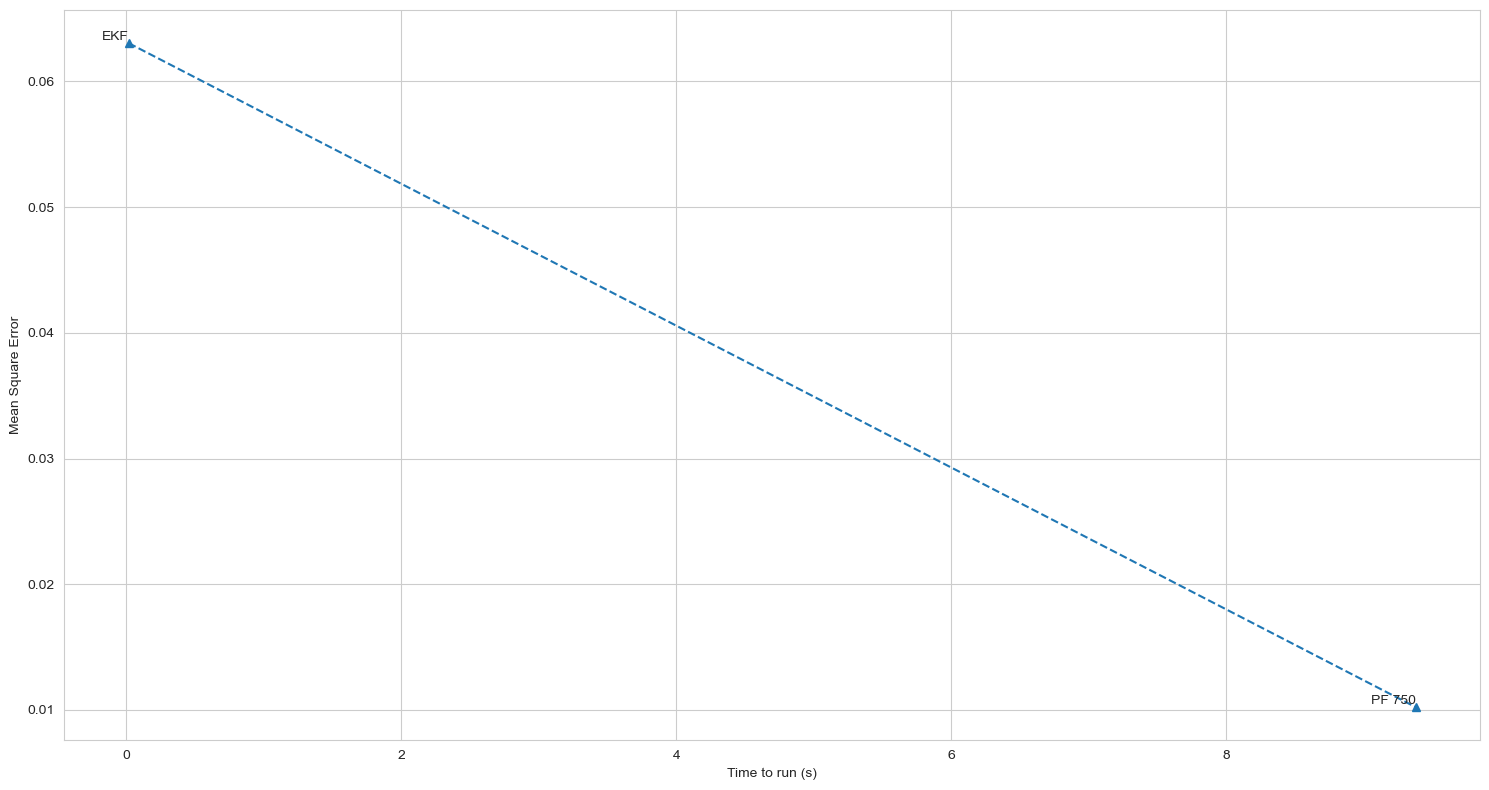

In [6]:
total_avg_time = np.average(time_arr_03, axis=(0, 2))
total_avg_err = np.average(error_arr_03, axis=(0, 2, 3))

fig, ax = plt.subplots(figsize=(15, 8))
ax.plot(total_avg_time, total_avg_err, linestyle="--", marker="^")
ax.set_xlabel("Time to run (s)")
ax.set_ylabel("Mean Square Error")
for x, y, label in zip(total_avg_time, total_avg_err, filters):
    ax.annotate(label, (x, y), ha="right", va="bottom")

fig.tight_layout()

In [7]:
print(total_avg_time)
print(total_avg_err)

[0.01644087 9.37749736]
[0.06304215 0.01022209]


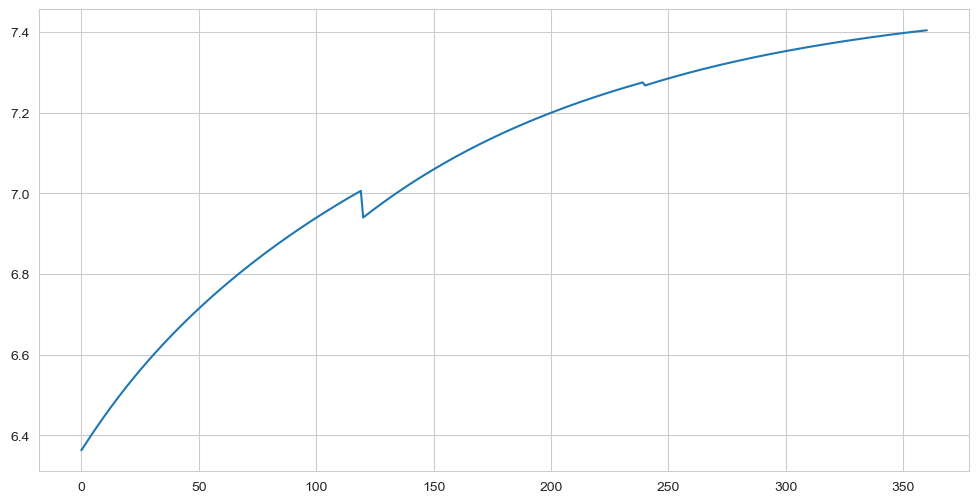

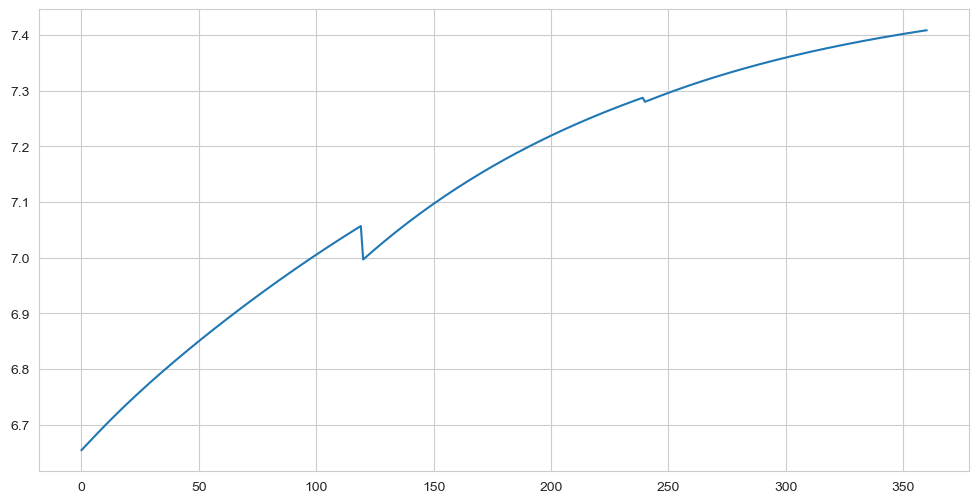

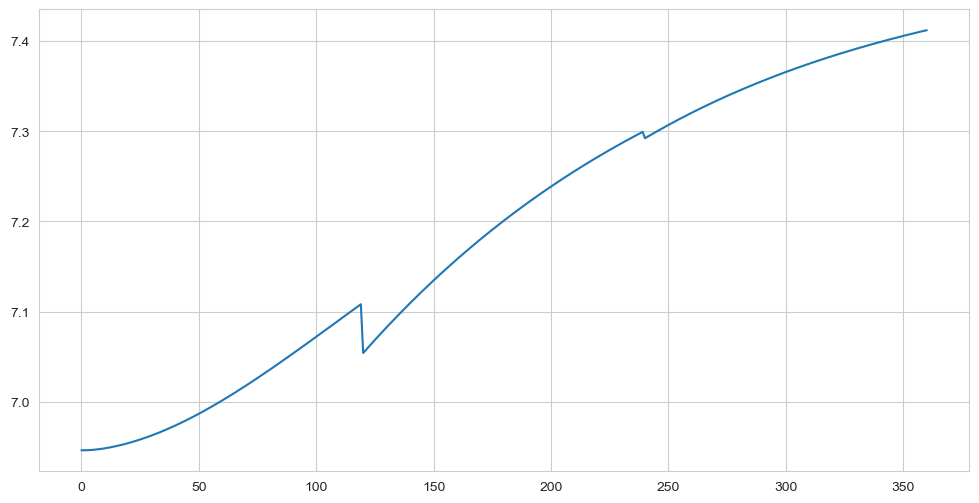

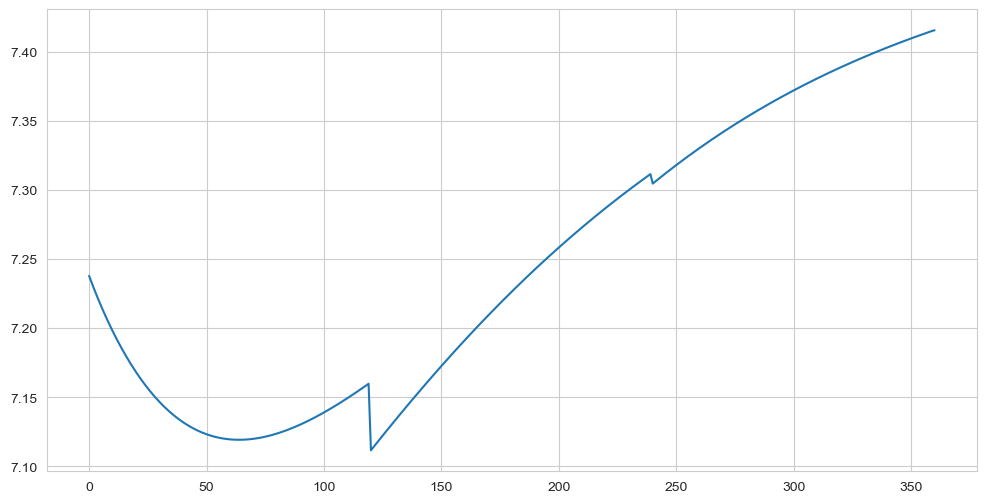

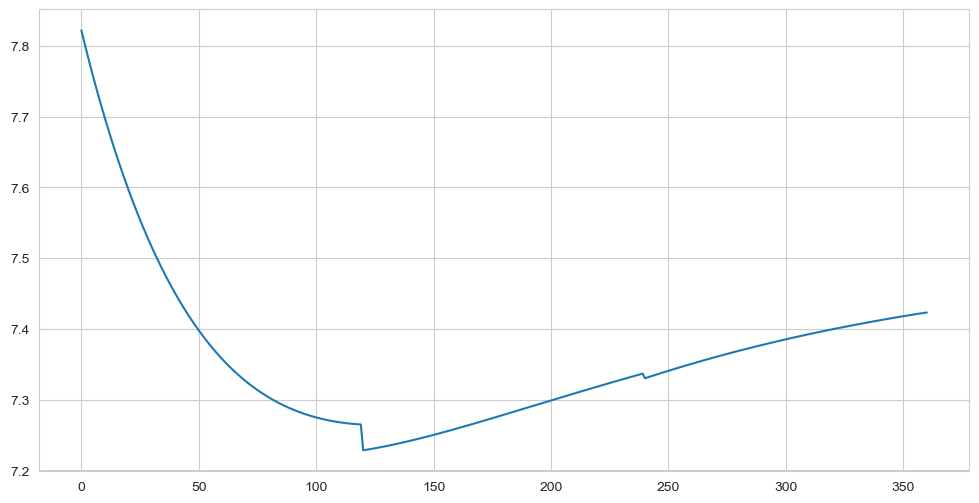

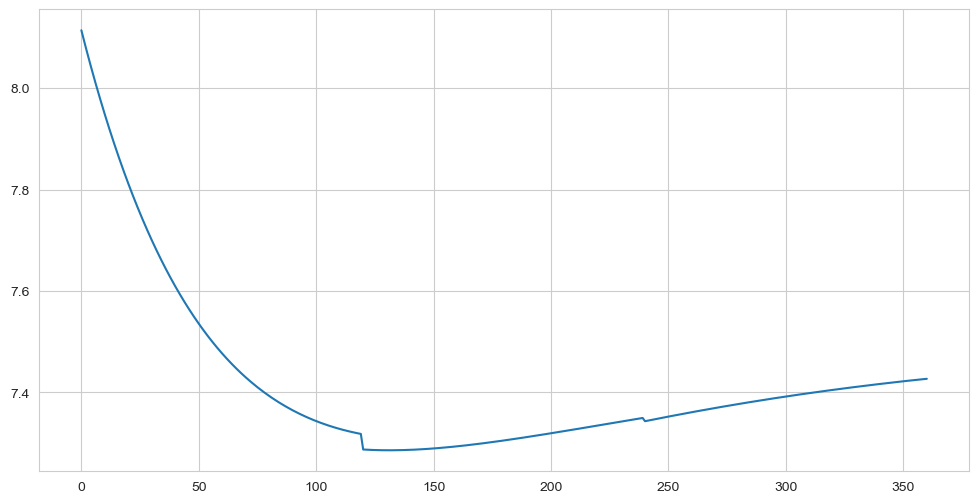

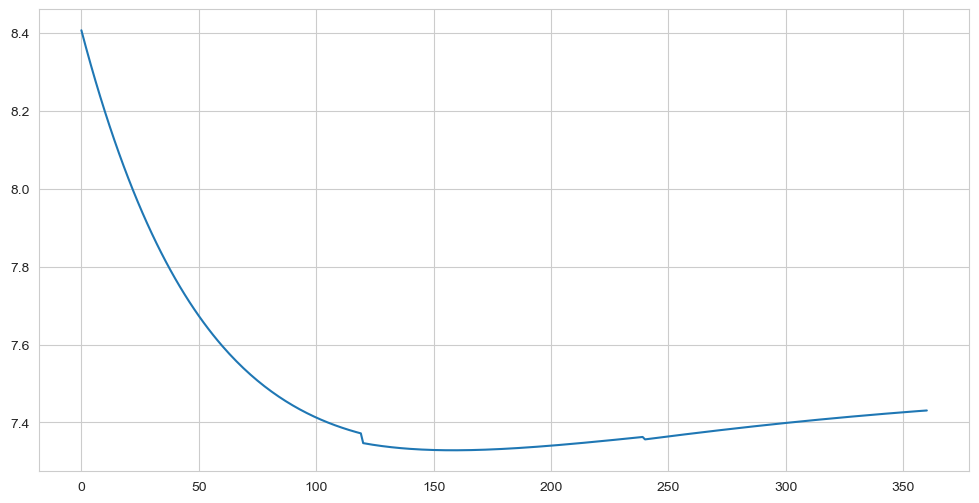

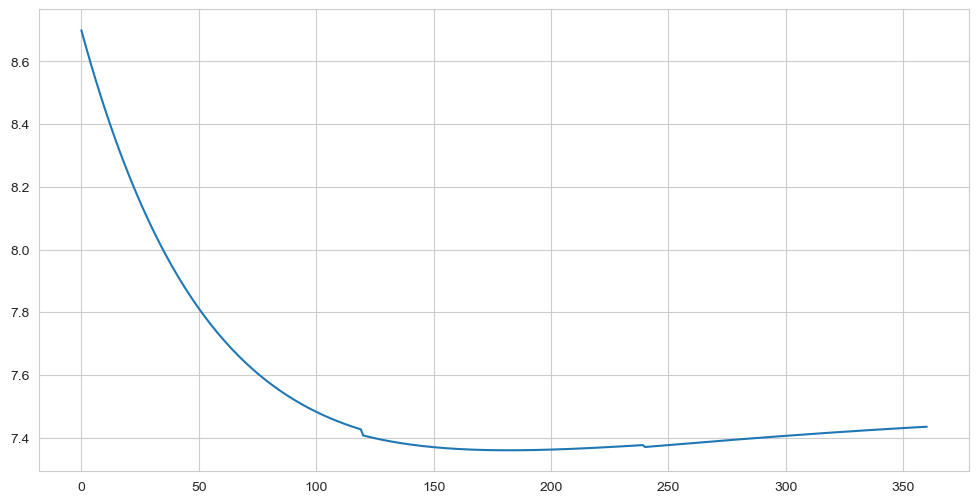

In [8]:
for i in range(num_deviations):
    fig, ax = plt.subplots(figsize=(12,6))
    ax.plot(G_ests[i,0,0,:])

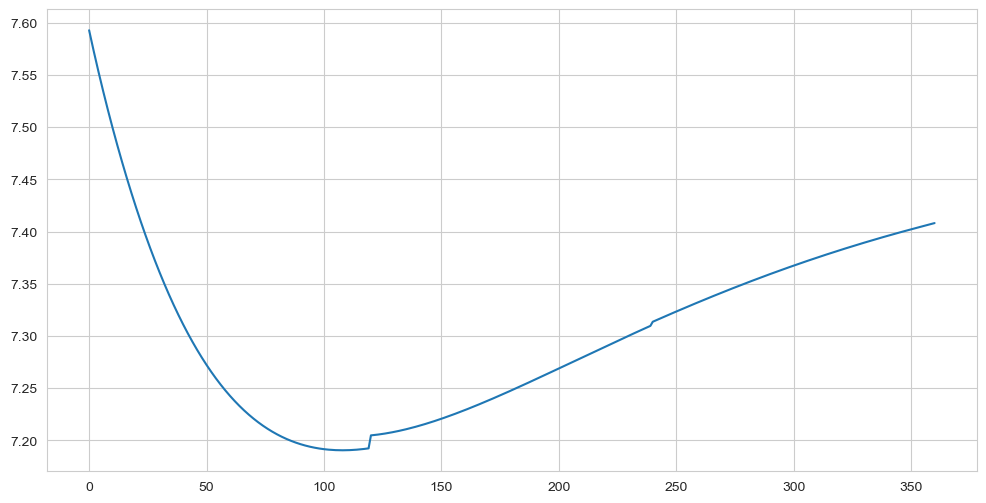

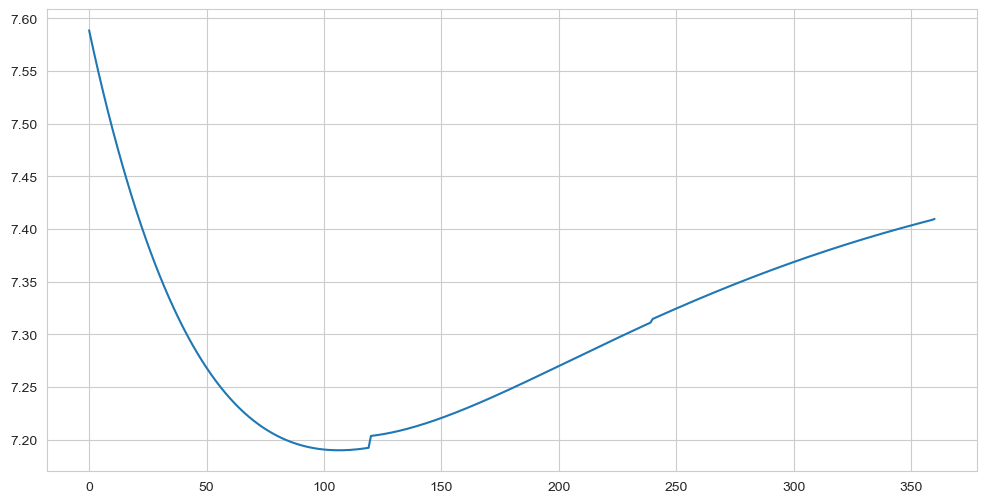

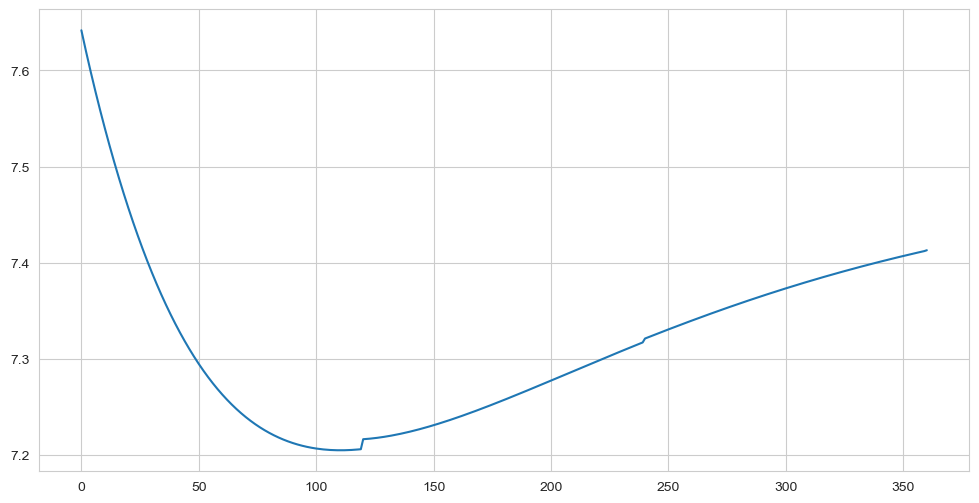

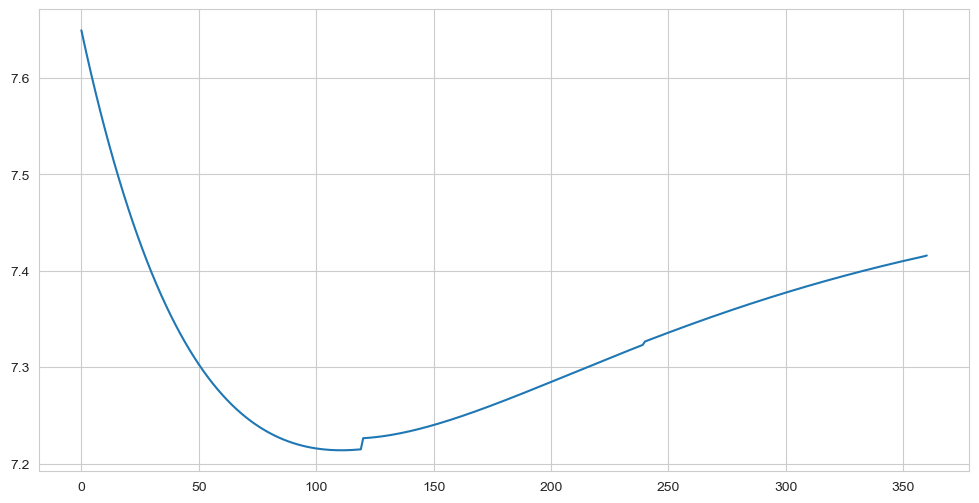

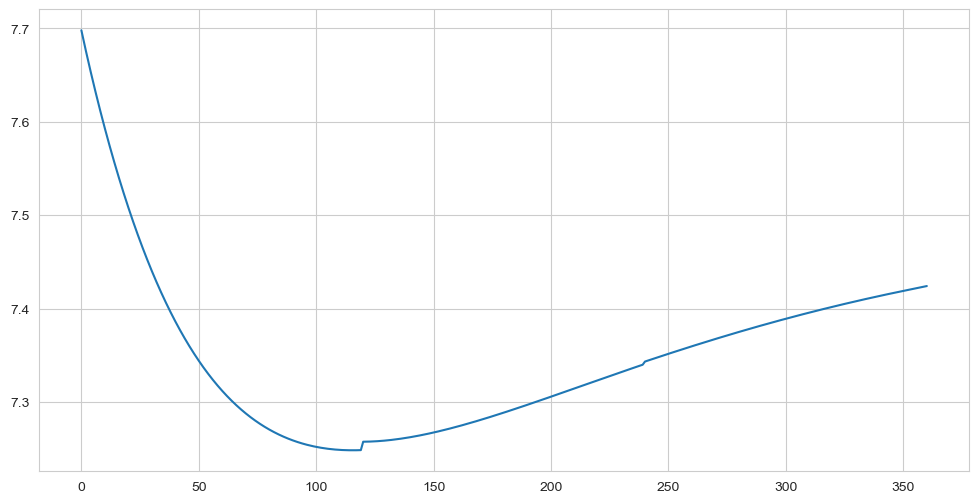

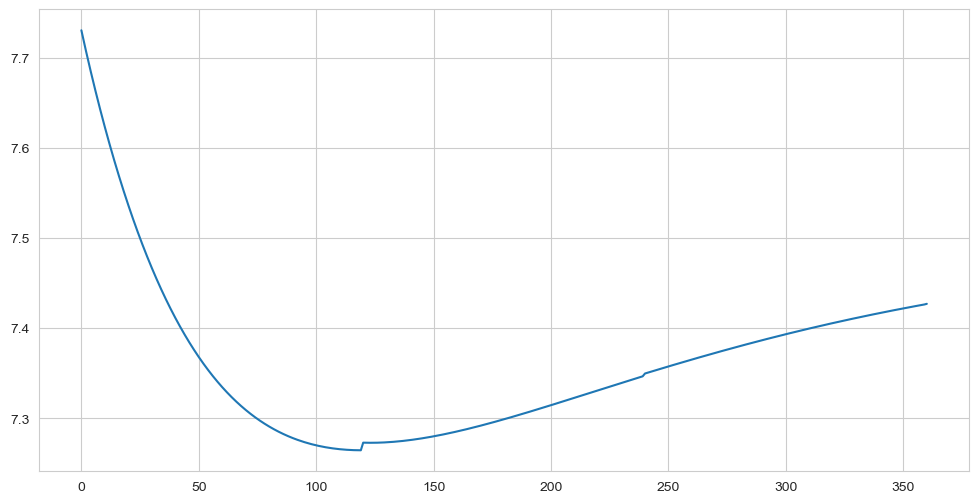

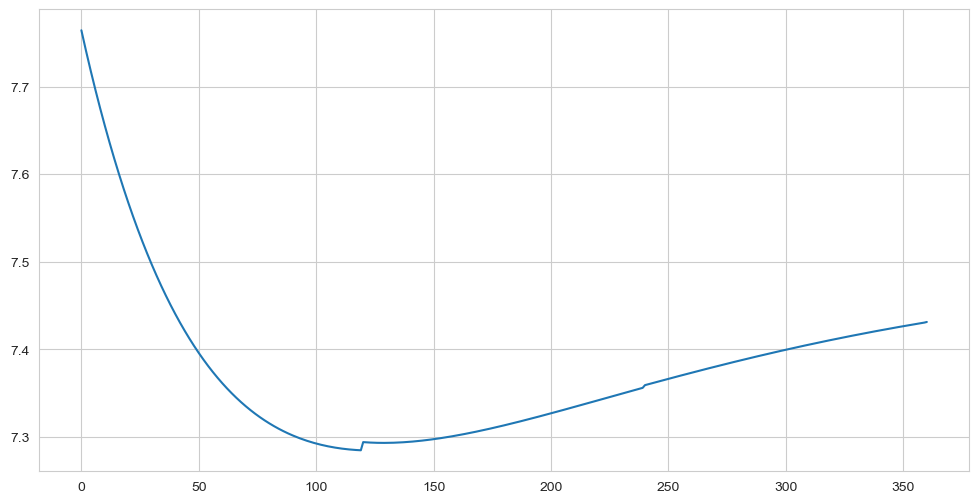

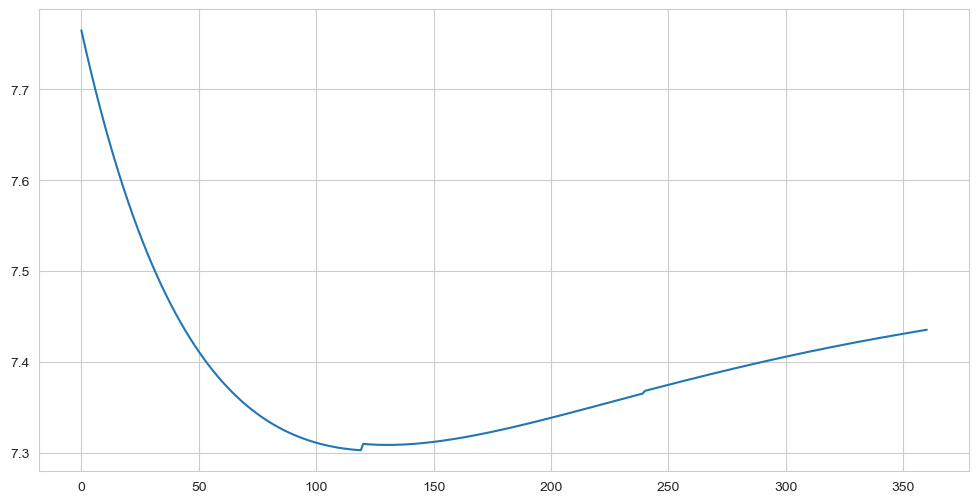

In [9]:
for i in range(num_deviations):
    fig, ax = plt.subplots(figsize=(12,6))
    ax.plot(G_ests[i,1,0,:])